<a href="https://colab.research.google.com/github/donatelk/kgdneuro265/blob/main/homework/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Kelsey Donatelli
*Neuro 265*

**4/9/2026**

In [23]:
#Import packages
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [7]:
#Import data
fear_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'
extinction_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
shock_url= 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv'
tone_url='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv'

fear_traces= np.loadtxt(fear_url, delimiter= ',')
extinction_predictors= np.loadtxt(extinction_url, delimiter= ',')
shock_index= np.loadtxt(shock_url, delimiter= ',').astype(int)
tone_index= np.loadtxt(tone_url, delimiter= ',').astype(int)

In [10]:
#Separate fear_traces into conditioning and extinction
conditioning_traces= fear_traces[0:10458]
extinction_traces= fear_traces[10458:]


In [11]:
#Size of new arrays
print(conditioning_traces.shape)
print(extinction_traces.shape)

(10458, 63)
(14210, 63)


In [12]:
#Make time variables
time_conditioning= np.linspace(0, 10458/15, 10458)
time_extinction= np.linspace(0, 14210/15, 14210)

There were 63 ROI cells were imaged. The total time is 697.2 seconds (or 11.6 minutes) for the conditioning session. The total time is 947.3 seconds (or 15.8 minutes) for the extinction session.

Text(0.5, 1.0, '1st and 2nd ROIs for the Extinction Session')

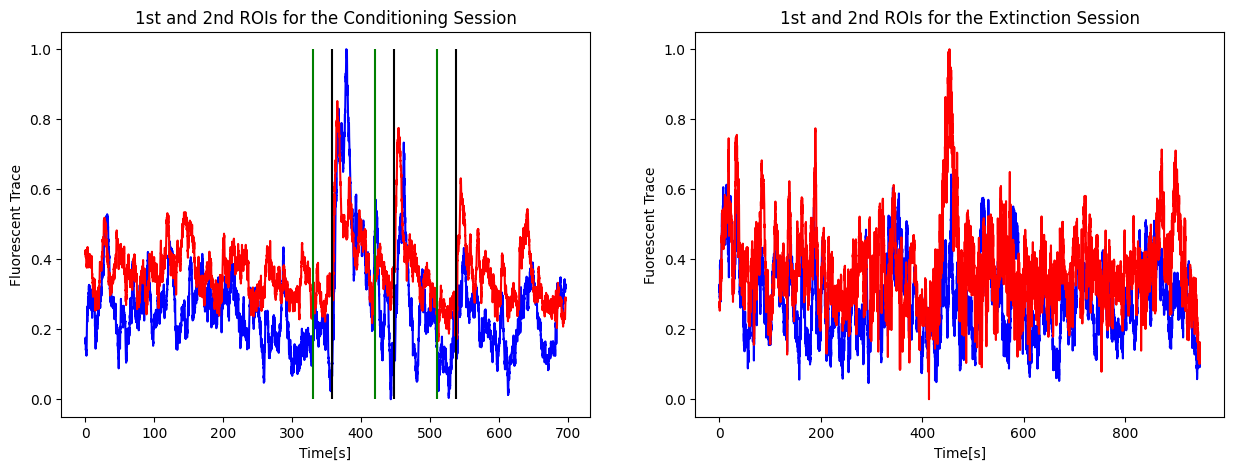

In [16]:
#Plot of first and second ROIs for conditioning and extinction sessions
fig, ax = plt.subplots(1,2,figsize=(15,5))

#conditioning session
ax[0].plot(time_conditioning, conditioning_traces[:,0], color= 'blue')
ax[0].plot(time_conditioning, conditioning_traces[:,1], color= 'red')
ax[0].vlines(shock_index, 0, 1, color= 'black')
ax[0].vlines(tone_index, 0, 1, color= 'green')
ax[0].set_xlabel('Time[s]')
ax[0].set_ylabel('Fluorescent Trace')
ax[0].set_title('1st and 2nd ROIs for the Conditioning Session')

#extinction session
ax[1].plot(time_extinction, extinction_traces[:,0], color= 'blue')
ax[1].plot(time_extinction, extinction_traces[:,1], color= 'red')
ax[1].set_xlabel('Time[s]')
ax[1].set_ylabel('Fuorescent Trace')
ax[1].set_title('1st and 2nd ROIs for the Extinction Session')


For the first ROI, there is a large trace in the conditioning session following the first shock, subsequent traces are smaller following the other two shocks. There are some peaks for the first ROI in the extinciton condtion, but not as clear of a pattern. For the second ROI, in the conditioning session the traces spike up closer to the shock, presumably in closer response to the tone. In the extinction session there is again not a clear pattern, but there does seem to be a larger spike around the time of the second tone.

In [20]:
#Make predictors_conditioning variable using example from class

shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

from pandas import DataFrame as df
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson
from statsmodels.genmod.families.links import identity, log
from scipy.stats import chi2
from statsmodels.distributions.empirical_distribution import ECDF

first_trace = conditioning_traces[:,0]

predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
predictors_conditioning['shock onset']= shock_array
model3 = sm.GLM(first_trace, predictors_conditioning, family=Poisson())
model3_results = model3.fit() # Fit model to our data
b1 = model3_results.params
print('b1:')
print(b1)


b1:
Intercept     -1.346329
tone onset    -0.431768
shock onset    0.411876
dtype: float64


In [29]:
#Run model for each ROI for conditioning

r_index_conditioning = np.zeros(63)   #based on the instructions I was confused on if this should be named r_model_conditioning or r_index_conditioning

for i in range(63):
  trace_temp = conditioning_traces[:,i]
  model_conditioning = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model_conditioning_results = model_conditioning.fit()
  predicted_trace = model_conditioning_results.predict()
  r = stats.pearsonr(trace_temp, predicted_trace)      #I imported scipy stats before, but for some reason this only worked when I use stats.pearsonr, unlike the class notebook
  r_index_conditioning[i] = r.statistic


In [39]:
#Run model for each ROI for extinction

extinction_tone_array = np.zeros(14210)

for i in range(14210):
    if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
        extinction_tone_array[i] = 1
    elif i >= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
        extinction_tone_array[i] = 1
    elif i >= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
        extinction_tone_array[i] = 1
    else:
        extinction_tone_array[i] = 0

predictors_extinction = df(data={'Intercept': np.ones_like(extinction_tone_array),'tone onset': extinction_tone_array})

r_index_extinction= np.zeros(63)

for i in range(63):
  trace_temp = extinction_traces[:,i]
  model_extinction = sm.GLM(trace_temp, predictors_extinction, family=Poisson())
  model_extinction_results = model_extinction.fit()
  predicted_trace = model_extinction_results.predict()
  r = stats.pearsonr(trace_temp, predicted_trace)
  r_index_extinction[i] = r.statistic

In [43]:
#Correlate variables
r_correlation= stats.pearsonr(r_index_conditioning, r_index_extinction)
print(r_correlation)

PearsonRResult(statistic=np.float64(0.12619688891011477), pvalue=np.float64(0.3243560127180349))


Text(0.5, 1.0, 'Relationship between condition and extinction sessions')

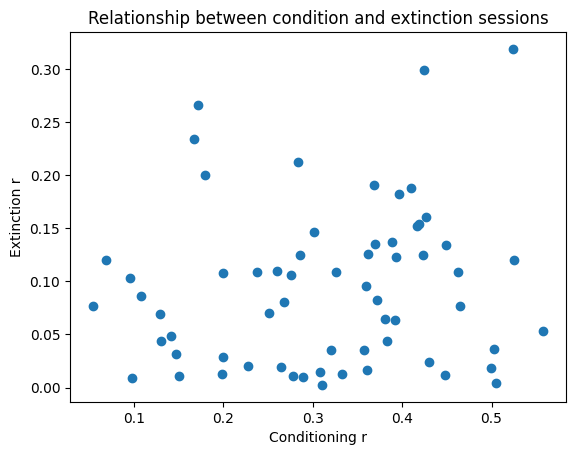

In [44]:
#Scatter plot comparing conditioning and extinction correlations
plt.scatter(r_index_conditioning, r_index_extinction)
plt.xlabel('Conditioning r')
plt.ylabel('Extinction r')
plt.title('Relationship between condition and extinction sessions')


Given that the r correlation value had a p of 0.32, and there is not much correlation between the points on the scatter plot, I would say that the cells that respond strongly to shock and tone onset during conditioning are not more likely to respond during extinction.  